In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("../data/processed/model_ready_dataset.csv")

df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date")

print(df.columns.tolist())

['Date', 'NVDA_Open', 'NVDA_High', 'NVDA_Low', 'NVDA_Close', 'NVDA_Volume', 'SP500_Open', 'SP500_High', 'SP500_Low', 'SP500_Close', 'SP500_Volume', 'Gold_Open', 'Gold_High', 'Gold_Low', 'Gold_Close', 'Gold_Volume', 'Oil_Open', 'Oil_High', 'Oil_Low', 'Oil_Close', 'Oil_Volume', 'Treasury10Y_Open', 'Treasury10Y_High', 'Treasury10Y_Low', 'Treasury10Y_Close', 'Treasury10Y_Volume', 'VIX_Open', 'VIX_High', 'VIX_Low', 'VIX_Close', 'VIX_Volume', 'NVDA_Return', 'NVDA_SMA_7', 'NVDA_SMA_30', 'NVDA_SMA_90', 'NVDA_EMA_12', 'NVDA_EMA_26', 'NVDA_MACD', 'NVDA_MACD_Signal', 'NVDA_Volatility_7', 'NVDA_Volatility_30', 'NVDA_Close_Lag_1', 'NVDA_Close_Lag_7', 'NVDA_Close_Lag_30', 'Target_Next_Close']


In [2]:
target_col = "NVDA_Close"

exog_cols = [
    "SP500_Close",
    "Gold_Close",
    "Oil_Close",
    "Treasury10Y_Close",
    "VIX_Close",
    "NVDA_Return",
    "NVDA_Volatility_30",
    "NVDA_MACD"
]

In [3]:
data = df[["Date", target_col] + exog_cols].copy()
data = data.dropna()
data = data.set_index("Date")

y = data[target_col]
X = data[exog_cols]

In [4]:
split_index = int(len(data) * 0.8)

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

print("Train:", y_train.index.min(), "to", y_train.index.max())
print("Test:", y_test.index.min(), "to", y_test.index.max())

Train: 2010-05-12 00:00:00 to 2022-11-09 00:00:00
Test: 2022-11-10 00:00:00 to 2025-12-30 00:00:00


In [5]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
sarimax_model = SARIMAX(
    y_train,
    exog=X_train_scaled,
    order=(5, 1, 0),
    seasonal_order=(0, 0, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarimax_fit = sarimax_model.fit(disp=False)

print(sarimax_fit.summary())

c:\Users\akshat\OneDrive\Desktop\stock prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\akshat\OneDrive\Desktop\stock prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\akshat\OneDrive\Desktop\stock prediction\.venv\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                               SARIMAX Results                                
Dep. Variable:             NVDA_Close   No. Observations:                 3148
Model:               SARIMAX(5, 1, 0)   Log Likelihood                1039.562
Date:                Fri, 03 Jul 2026   AIC                          -2051.124
Time:                        20:38:07   BIC                          -1966.388
Sample:                             0   HQIC                         -2020.717
                               - 3148                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
x1             4.1491      0.093     44.509      0.000       3.966       4.332
x2            -0.1448      0.041     -3.514      0.000      -0.226      -0.064
x3            -0.0991      0.021     -4.673      0.0

In [7]:
forecast = sarimax_fit.forecast(
    steps=len(y_test),
    exog=X_test_scaled
)

results = pd.DataFrame({
    "Actual": y_test.values,
    "Forecast": forecast.values
}, index=y_test.index)

c:\Users\akshat\OneDrive\Desktop\stock prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\akshat\OneDrive\Desktop\stock prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


In [8]:
mae = mean_absolute_error(results["Actual"], results["Forecast"])
rmse = np.sqrt(mean_squared_error(results["Actual"], results["Forecast"]))
r2 = r2_score(results["Actual"], results["Forecast"])

print("SARIMAX Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

SARIMAX Results
MAE: 71.99788595382303
RMSE: 88.07693355463715
R2 Score: -1.5434635368162466


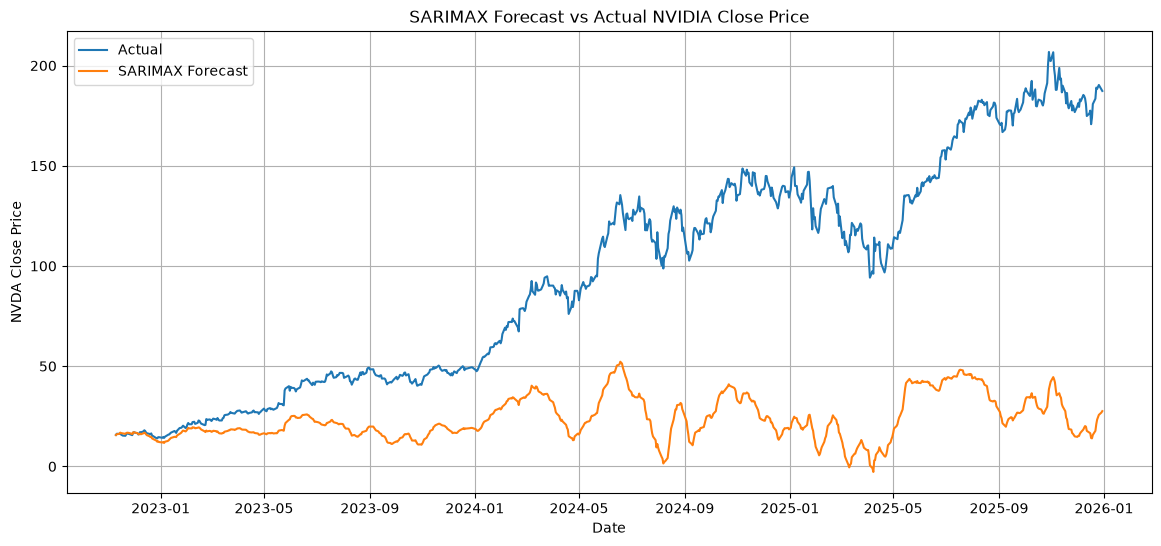

In [9]:
plt.figure(figsize=(14, 6))
plt.plot(results.index, results["Actual"], label="Actual")
plt.plot(results.index, results["Forecast"], label="SARIMAX Forecast")

plt.title("SARIMAX Forecast vs Actual NVIDIA Close Price")
plt.xlabel("Date")
plt.ylabel("NVDA Close Price")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

target_col = "NVDA_Close"

exog_cols = [
    "SP500_Close",
    "Gold_Close",
    "Oil_Close",
    "Treasury10Y_Close",
    "VIX_Close"
]

data = df[["Date", target_col] + exog_cols].dropna().copy()
data["Date"] = pd.to_datetime(data["Date"])
data = data.sort_values("Date")
data = data.set_index("Date")

y = data[target_col]
X = data[exog_cols]

split_index = int(len(data) * 0.8)

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

history_y = list(y_train)
history_X = X_train.copy()

predictions = []

for i in range(len(y_test)):
    model = SARIMAX(
        history_y,
        exog=history_X,
        order=(5, 1, 0),
        seasonal_order=(0, 0, 0, 0),
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    model_fit = model.fit(disp=False)

    next_exog = X_test.iloc[[i]]

    yhat = model_fit.forecast(steps=1, exog=next_exog).iloc[0]

    predictions.append(yhat)

    history_y.append(y_test.iloc[i])
    history_X = pd.concat([history_X, next_exog])

results_sarimax_walk = pd.DataFrame({
    "Actual": y_test.values,
    "Forecast": predictions
}, index=y_test.index)

mae = mean_absolute_error(results_sarimax_walk["Actual"], results_sarimax_walk["Forecast"])
rmse = np.sqrt(mean_squared_error(results_sarimax_walk["Actual"], results_sarimax_walk["Forecast"]))
r2 = r2_score(results_sarimax_walk["Actual"], results_sarimax_walk["Forecast"])

print("Walk-Forward SARIMAX Results")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

c:\Users\akshat\OneDrive\Desktop\stock prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\akshat\OneDrive\Desktop\stock prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\akshat\OneDrive\Desktop\stock prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\akshat\OneDrive\Desktop\stock prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In 

Walk-Forward SARIMAX Results
MAE: 1.811193626260645
RMSE: 2.7744799908415345
R2 Score: 0.9974761453616131


c:\Users\akshat\OneDrive\Desktop\stock prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\akshat\OneDrive\Desktop\stock prediction\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


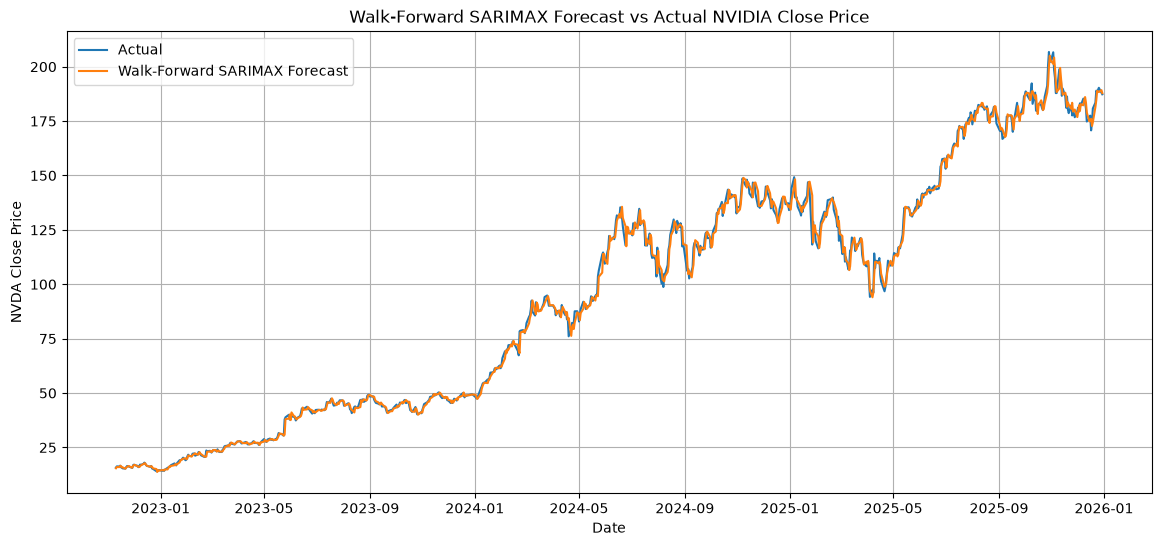

In [12]:
plt.figure(figsize=(14, 6))
plt.plot(results_sarimax_walk.index, results_sarimax_walk["Actual"], label="Actual")
plt.plot(results_sarimax_walk.index, results_sarimax_walk["Forecast"], label="Walk-Forward SARIMAX Forecast")

plt.title("Walk-Forward SARIMAX Forecast vs Actual NVIDIA Close Price")
plt.xlabel("Date")
plt.ylabel("NVDA Close Price")
plt.legend()
plt.grid(True)
plt.show()

In [13]:
mape_sarimax = np.mean(
    np.abs((results_sarimax_walk["Actual"] - results_sarimax_walk["Forecast"]) / results_sarimax_walk["Actual"])
) * 100

print("SARIMAX MAPE:", mape_sarimax)

SARIMAX MAPE: 1.9145975416754624
